In [19]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

### 1. Setting up Configurations

In [20]:
RAW_DATA_PATH = Path('../../data/raw/Telco-Customer-Churn.csv')
PROCESSED_DATA_PATH = Path('../../data/processed')
ARTIFACTS_DIR = Path('../../artifacts')
FIGURE_DIR = Path('../../artifacts/figures')

### 2. Load Data

In [21]:
df = pd.read_csv(f"{PROCESSED_DATA_PATH}/ handled_missing_value.csv")

In [22]:
df.head(5)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 3. Univariant Analysis

#### 3.1 Split Numerical and Categorical columns

In [23]:
df_columns = df.columns
df_columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [24]:
numerical_col = []
categorical_col = []

for col in df_columns:
    if df[col].dtype == 'object':
        categorical_col.append(col)
    else:
        numerical_col.append(col)

print(f"Numerical columns : {numerical_col}")
print(f"Categorical columns : {categorical_col}")

Numerical columns : ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical columns : ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


#### 3.2 Numerical Features Analysis

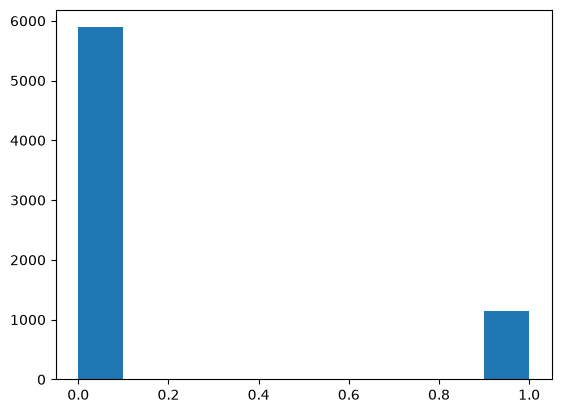

In [25]:
plt.hist(df['SeniorCitizen'])
plt.savefig(FIGURE_DIR / "eda_senior_citizen.png", dpi=150, bbox_inches='tight')

- The data type is int, but this is not actually continuous 

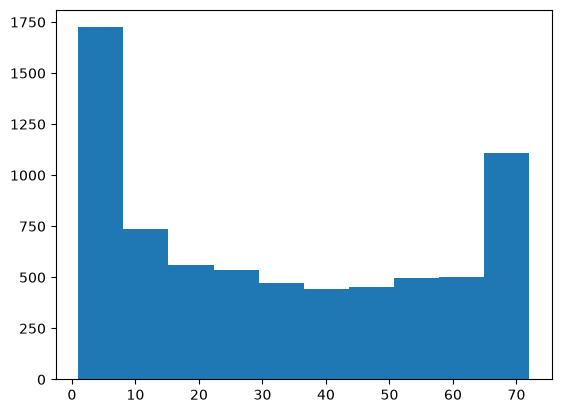

In [26]:
plt.hist(df['tenure'])
plt.savefig(FIGURE_DIR / "eda_tenure.png")

  - High spike at 0–5 months (1,600 customers) → early churn / onboarding risk
  - Flat middle band at 10–65 months (450–550 per bin) → stable retained customers
  - Late spike at 65–72 months (1,100 customers) → long-term loyal base

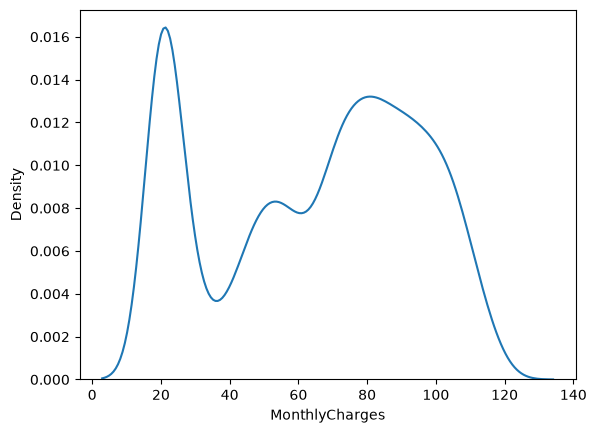

In [27]:
sns.kdeplot(df['MonthlyCharges'])
plt.savefig(FIGURE_DIR / "eda_monthly_charges.png")

- Large spike at $20–30 (1,600 customers) → low-tier/basic plan segment 
- Second peak at $80–90 (950 customers) → premium plan segment

#### 3.3 Categorical Feature Analysis

In [28]:
categorical_col

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn']

In [29]:
"""
    Gruop feature names in to different categories for better understanding,
        - demographic_features
        - phone_service_features
        - internet_service_features
        - billing_features
        - target

    Define function for analys each feature get precentages 
"""

target = ['Churn']
demographic_features = ['gender', 'Partner', 'Dependents']
phone_service_features = ['PhoneService', 'MultipleLines']
billing_features = ['Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges']
internet_service_features = [
                                'InternetService', 
                                'OnlineSecurity', 
                                'OnlineBackup', 
                                'DeviceProtection', 
                                'TechSupport', 
                                'StreamingTV', 
                                'StreamingMovies'
                            ]



In [30]:
feature_groups = {
                    "demographic": [
                        'gender', 'SeniorCitizen', 'Partner', 'Dependents'
                    ],
                    "behavioral": [
                        'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
                        'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                        'TechSupport', 'StreamingTV', 'StreamingMovies',
                        'Contract', 'PaperlessBilling'
                    ],
                    "financial": [
                        'PaymentMethod', 'MonthlyCharges', 'TotalCharges'
                    ],
                    "target": ['Churn']
                }

for key, value in feature_groups.items():
    print(key , value)

demographic ['gender', 'SeniorCitizen', 'Partner', 'Dependents']
behavioral ['tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling']
financial ['PaymentMethod', 'MonthlyCharges', 'TotalCharges']
target ['Churn']


In [31]:
# this is analys categorical feature in description way 

def analysis_categorical_features(feature_names:list, df):
    for i in feature_names:
        analysis = df[i].value_counts(normalize=True)
        print(analysis)
        print("\t")


# this visualize fetures their count

def univaiant_visualize(feature_cat:list, df):

    num_features = len(feature_cat)
    n_raw = 1 if num_features <= 3 else 2 if num_features <= 6 else 3
    n_col = len(feature_cat) if n_raw == 1 else 3

    figsize_h = 16 if n_raw <= 2 else 20
    figsize_v = 5 if n_raw <= 2 else 10
    fig, axes = plt.subplots(n_raw, n_col, figsize = (figsize_h , figsize_v))
    axes = np.atleast_1d(axes).flatten()

    for idx, col in enumerate(feature_cat):
        sns.countplot(data = df, x = col, ax = axes[idx], hue='Churn')
        axes[idx].set_title(col)
        axes[idx].set_xlabel(' ')

    plt.show()

#### Demographic Feature Analysis and Visualization

gender
Male      0.504693
Female    0.495307
Name: proportion, dtype: float64
	
Partner
No     0.517491
Yes    0.482509
Name: proportion, dtype: float64
	
Dependents
No     0.701507
Yes    0.298493
Name: proportion, dtype: float64
	


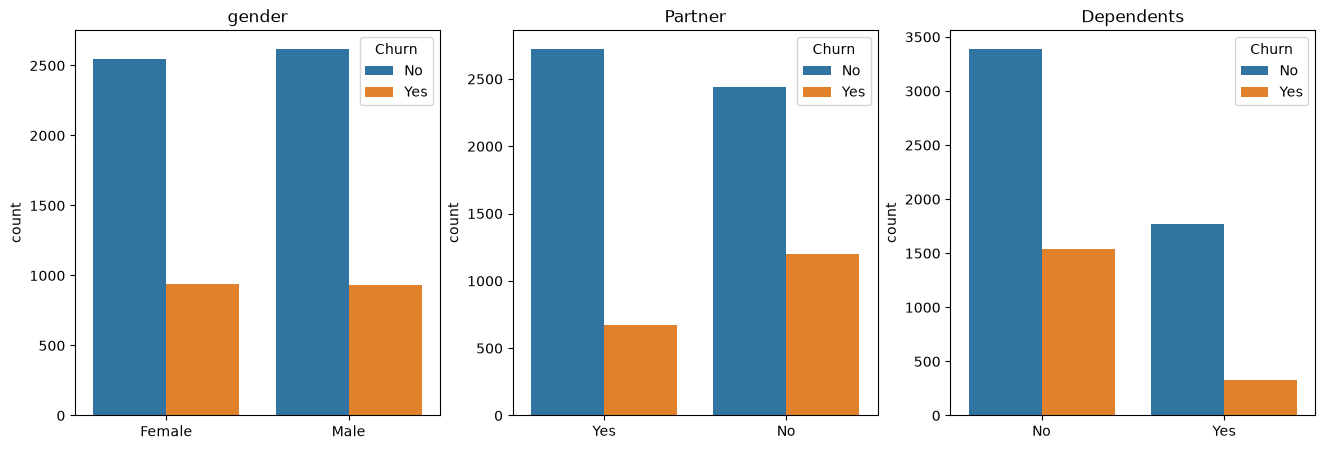

In [32]:
analysis_categorical_features(demographic_features, df)
univaiant_visualize(demographic_features, df)

#### Phone Service Features Feature Analysis and Visualization

PhoneService
Yes    0.903299
No     0.096701
Name: proportion, dtype: float64
	
MultipleLines
No                  0.481371
Yes                 0.421928
No phone service    0.096701
Name: proportion, dtype: float64
	


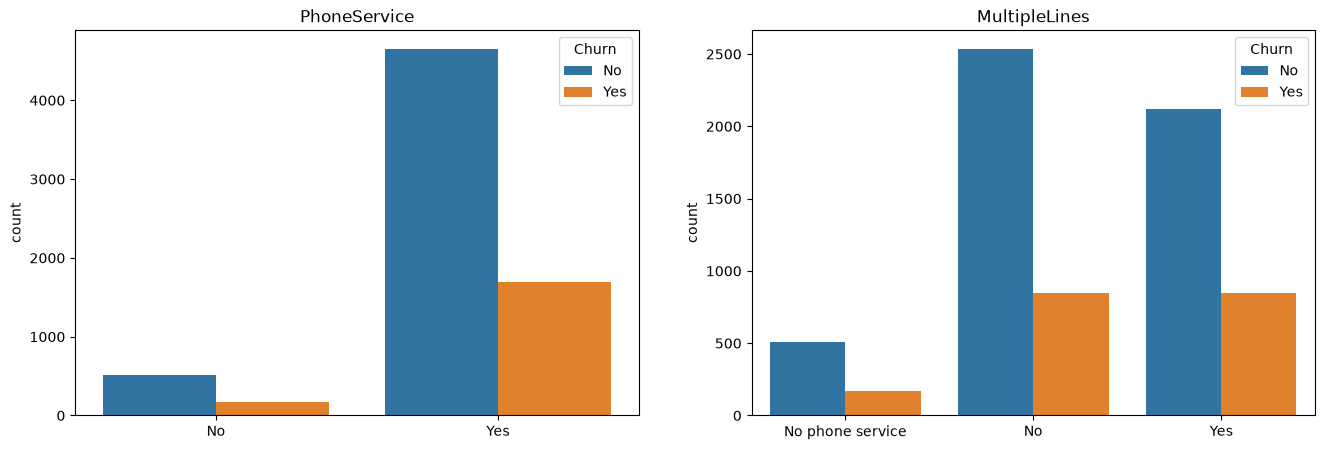

In [33]:
analysis_categorical_features(phone_service_features, df)
univaiant_visualize(phone_service_features, df)

#### Internet Service Features and Visualization

InternetService
Fiber optic    0.440273
DSL            0.343572
No             0.216155
Name: proportion, dtype: float64
	
OnlineSecurity
No                     0.497298
Yes                    0.286547
No internet service    0.216155
Name: proportion, dtype: float64
	
OnlineBackup
No                     0.438993
Yes                    0.344852
No internet service    0.216155
Name: proportion, dtype: float64
	
DeviceProtection
No                     0.439989
Yes                    0.343857
No internet service    0.216155
Name: proportion, dtype: float64
	
TechSupport
No                     0.493743
Yes                    0.290102
No internet service    0.216155
Name: proportion, dtype: float64
	
StreamingTV
No                     0.399460
Yes                    0.384386
No internet service    0.216155
Name: proportion, dtype: float64
	
StreamingMovies
No                     0.395478
Yes                    0.388367
No internet service    0.216155
Name: proportion, dtype: float64
	


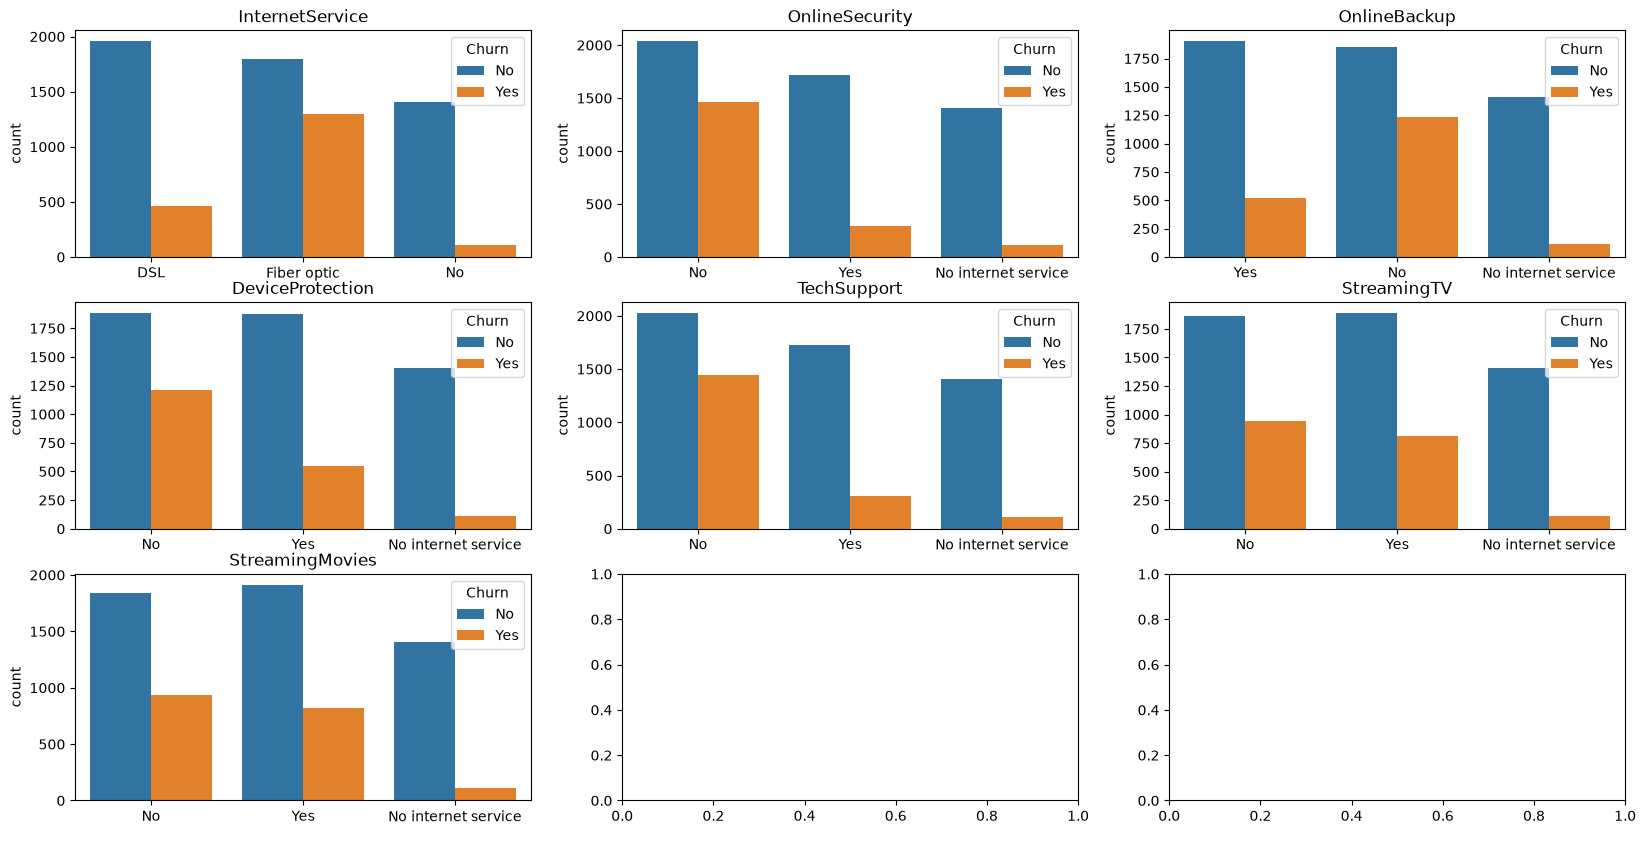

In [34]:
analysis_categorical_features(internet_service_features, df)
univaiant_visualize(internet_service_features, df)

#### Billing Features and Visualization

Contract
Month-to-month    0.551052
Two year          0.239619
One year          0.209329
Name: proportion, dtype: float64
	
PaperlessBilling
Yes    0.592719
No     0.407281
Name: proportion, dtype: float64
	
PaymentMethod
Electronic check             0.336320
Mailed check                 0.228100
Bank transfer (automatic)    0.219283
Credit card (automatic)      0.216297
Name: proportion, dtype: float64
	
TotalCharges
20.20      0.001564
19.75      0.001280
19.90      0.001138
19.65      0.001138
20.05      0.001138
             ...   
1990.50    0.000142
7362.90    0.000142
346.45     0.000142
306.60     0.000142
6844.50    0.000142
Name: proportion, Length: 6530, dtype: float64
	


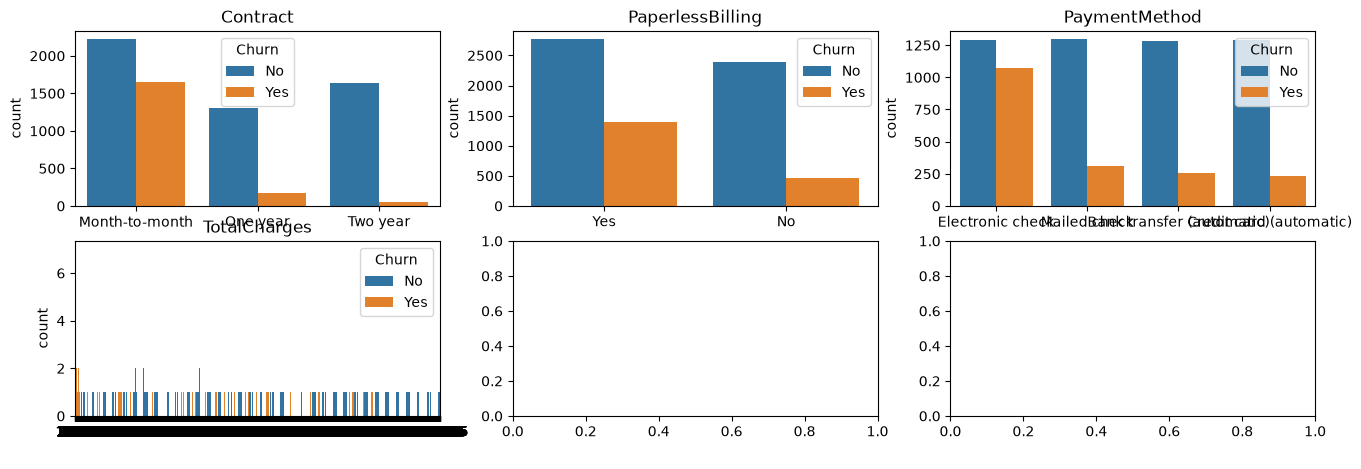

In [35]:
analysis_categorical_features(billing_features, df)
univaiant_visualize(billing_features, df)

#### Target Features and Visualization

Churn
No     0.734215
Yes    0.265785
Name: proportion, dtype: float64
	


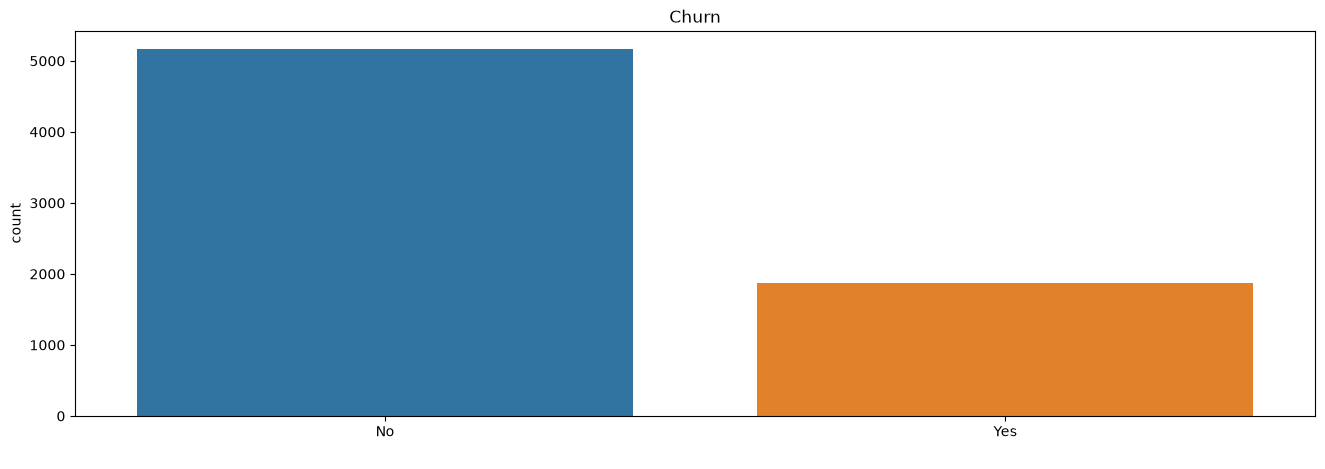

In [36]:
analysis_categorical_features(target, df)
univaiant_visualize(target, df)

### 4. Outlier detection

##### 4.1 Visualization

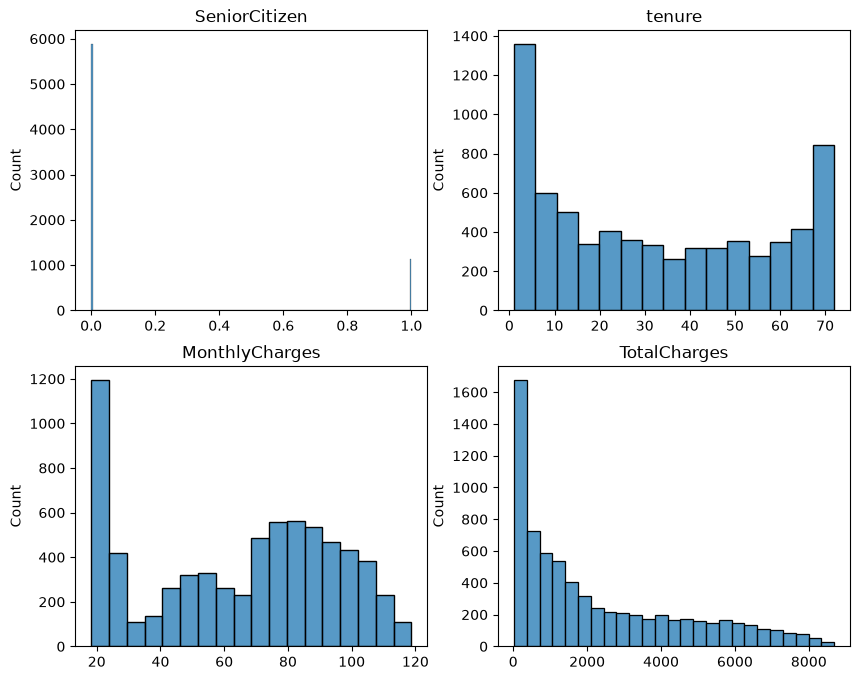

In [37]:
fig, axes = plt.subplots(2, 2, figsize=(10,8))
axes = axes.flatten()

for idx, col in enumerate(numerical_col):
    sns.histplot(data=df[col], ax=axes[idx])
    axes[idx].set_title(col)
    axes[idx].set_xlabel('')

<Axes: ylabel='SeniorCitizen'>

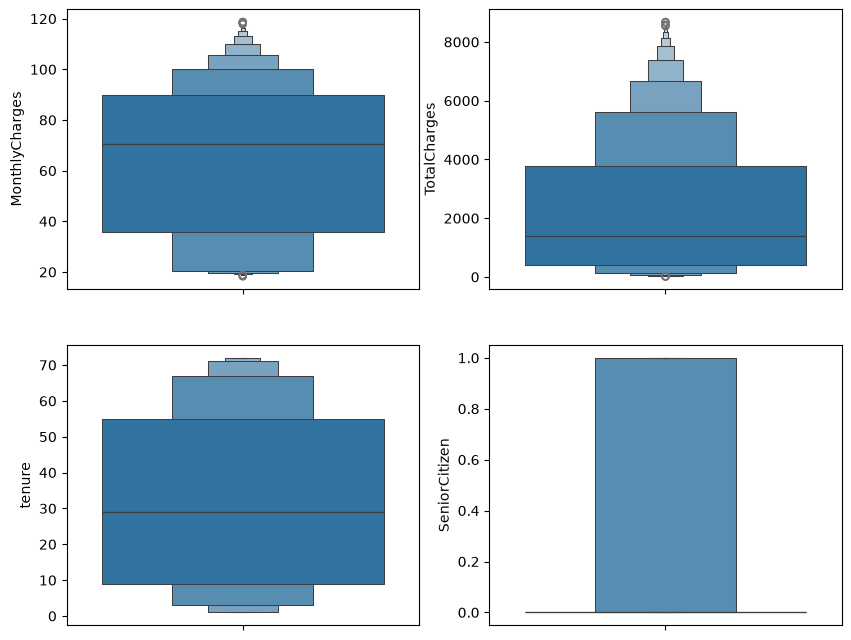

In [38]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

sns.boxenplot(data= df['MonthlyCharges'], ax=axes[0, 0])
sns.boxenplot(data= df['TotalCharges'], ax=axes[0, 1])
sns.boxenplot(data= df['tenure'], ax=axes[1, 0])
sns.boxenplot(data= df['SeniorCitizen'], ax=axes[1, 1])

##### 4.2 Detect Outlier using Z-score

In [39]:
"""
    z = (x - mean)/std
    After calculated z score we need to apply threshold value
    as range to filter outlier

"""

def outlier_detection_zscore(col):
    upper_threshold = 3
    lower_threshold = -3
    mean = np.mean(df[col])
    std = np.std(df[col])

    z = (df[col] - mean) / std

    return (z > upper_threshold) | (z < lower_threshold)

In [40]:
for i in numerical_col:
    n_outlier = outlier_detection_zscore(i).sum()
    pct_outlier = (n_outlier / len(df)) * 100
    print(f"{i} has : {n_outlier} outliers, as precentage : {pct_outlier:.2f}")

print("using z-score")

SeniorCitizen has : 0 outliers, as precentage : 0.00
tenure has : 0 outliers, as precentage : 0.00
MonthlyCharges has : 0 outliers, as precentage : 0.00
TotalCharges has : 0 outliers, as precentage : 0.00
using z-score


##### 4.3 Detect Outlier using IQR

In [41]:
"""
    Q1, Q3
    IQR
    upper bound
    lower bound
"""

from numpy.char import lower


def outlier_detection_iqr(col):
    Q1 = np.percentile(df[col], 25)
    Q3 = np.percentile(df[col], 75)

    IQR = Q3 - Q1

    upper_bound = Q3 + 1.5 * IQR
    lower_bound = Q1 - 1.5 * IQR

    return (df[col] > upper_bound) | (df[col] < lower_bound)



In [42]:
for i in numerical_col:
    n_outlier = outlier_detection_iqr(i).sum()
    pct_outlier = (n_outlier / len(df)) * 100
    print(f"{i} has : {n_outlier} outliers, as precentage : {pct_outlier:.2f}")

print("using IQR")

SeniorCitizen has : 1142 outliers, as precentage : 16.24
tenure has : 0 outliers, as precentage : 0.00
MonthlyCharges has : 0 outliers, as precentage : 0.00
TotalCharges has : 0 outliers, as precentage : 0.00
using IQR


### 7. Identify Feature Engineering

In [46]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [52]:
feature_eng_num = df[numerical_col]
feature_eng_cat = df[categorical_col]

# feature_eng_cat
feature_eng_num


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
0,0,1,29.85,29.85
1,0,34,56.95,1889.50
2,0,2,53.85,108.15
3,0,45,42.30,1840.75
4,0,2,70.70,151.65
...,...,...,...,...
7027,0,24,84.80,1990.50
7028,0,72,103.20,7362.90
7029,0,11,29.60,346.45
7030,1,4,74.40,306.60


In [ ]:
"""
    FEATURE ENGINEERING IDENTIFY : there are toomuch columns in this data set to process
    CATEGORICAL : [Ordinal, Nominal]
        - gender
        - Partner
        - Dependents
        - PhoneService	
        - MultipleLines	
        - InternetService	
        - OnlineSecurity	
        - OnlineBackup	
        - DeviceProtection	
        - TechSupport	
        - StreamingTV	
        - StreamingMovies	
        - Contract	
        - PaperlessBilling	
        - PaymentMethod
        - SeniorCitizen

    NUMERICAL :
        - tenure
        - MonthlyCharges
        - TotalCharges
"""

In [ ]:
df.head()


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
